# Wildfire Escalation Prediction in Northern California

### Research Question
Can we predict whether an active wildfire in Northern California's high-risk Sierra Nevada and Cascade counties (Butte, Plumas, Shasta, El Dorado, and Lassen) will remain stable or escalate in intensity (measured by Fire Radiative Power, FRP) 24 hours into the future by modeling satellite thermal anomalies alongside local daily meteorological and terrain data?

### Scope & Deliverables
This notebook implements the data ingestion, preprocessing, cleaning, exploratory data analysis, visualization, and baseline regression modeling for predicting wildfire escalation. The analysis is constrained to the following five counties:
- Butte
- Plumas
- Shasta
- El Dorado
- Lassen

## Environment Setup & County Boundaries Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set Seaborn style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14

print("Libraries successfully imported!")

Libraries successfully imported!


### Fetching and Filtering California County Boundaries
We load the California counties boundary GeoJSON dataset from a public repository and filter it to keep only our 5 target counties.

In [2]:
# URL for official US Census Bureau TIGERweb boundaries of California Counties
geojson_url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/State_County/MapServer/1/query?where=STATE%3D%2706%27&outFields=NAME%2CSTATE%2CCOUNTY&f=geojson"

print("Fetching California county boundaries...")
ca_counties = gpd.read_file(geojson_url)

target_counties_list = ["Butte", "Plumas", "Shasta", "El Dorado", "Lassen"]

# Clean the county name by removing " County" suffix (e.g. "Butte County" -> "Butte")
ca_counties['clean_name'] = ca_counties['NAME'].str.replace(' County', '', case=False).str.strip()
target_counties = ca_counties[ca_counties['clean_name'].isin(target_counties_list)]

print(f"Retrieved the following counties:\n{target_counties['NAME']}")

Fetching California county boundaries...


Retrieved the following counties:
2        Shasta County
16        Butte County
28       Plumas County
29       Lassen County
47    El Dorado County
Name: NAME, dtype: object


### Plotting Target Counties
We visualize the 5 target counties in Northern California to verify their spatial layout.

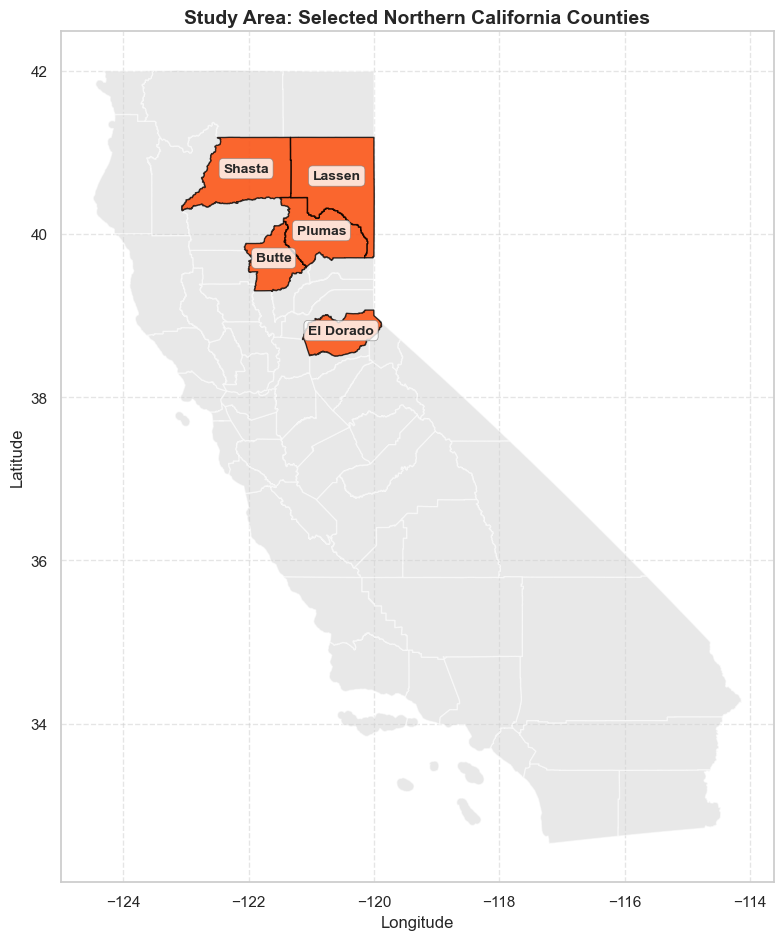

In [3]:
# Plot the counties
fig, ax = plt.subplots(figsize=(8, 10))
ca_counties.plot(ax=ax, color='lightgrey', edgecolor='white', alpha=0.5)
target_counties.plot(ax=ax, color='orangered', edgecolor='black', alpha=0.8)

# Add labels for our target counties
for idx, row in target_counties.iterrows():
    # Center the label
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['clean_name'], fontsize=10, fontweight='bold', ha='center',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", lw=0.5, alpha=0.8))

plt.title("Study Area: Selected Northern California Counties", fontsize=14, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('img/study_area_map.png', dpi=300)
plt.show()

## Active Fire Data Ingestion & Validation
In this phase, we fetch historical active fire observations from NASA's MODIS satellite spanning the 5-year period from 2020 to 2024. We filter the contiguous US dataset programmatically to California bounds, select high-confidence wildland fire observations, convert the timestamps from UTC to local California time (PST/PDT), and perform a spatial join to keep only the points located inside our 5 target counties.

In [4]:
# Bounding box for California
min_lat, max_lat = 32.0, 42.0
min_lon, max_lon = -124.0, -114.0

# Fetch MODIS active fire data for 2020-2024
years = [2020, 2021, 2022, 2023, 2024]
url_template = 'https://firms.modaps.eosdis.nasa.gov/data/country/modis/{year}/modis_{year}_United_States.csv'

combined_list = []

for year in years:
    url = url_template.format(year=year)
    print(f"Fetching MODIS data for {year}...")
    try: 
        # Read in chunks to filter on the fly (saves memory)
        chunks = pd.read_csv(url, chunksize=50000)
        for chunk in chunks:
            # Filter to California geographic bounding box
            filtered = chunk[
                (chunk['latitude'] >= min_lat) & (chunk['latitude'] <= max_lat) &
                (chunk['longitude'] >= min_lon) & (chunk['longitude'] <= max_lon)
            ]
            # Filter to wildland fires (type == 0) and high-confidence events (confidence >= 50%)
            filtered = filtered[(filtered['type'] == 0) & (filtered['confidence'] >= 50)]
            
            if not filtered.empty:
                norm_cols = {
                    'latitude': filtered['latitude'],
                    'longitude': filtered['longitude'],
                    'acq_date': filtered['acq_date'],
                    'acq_time': filtered['acq_time'],
                    'satellite': filtered['satellite'],
                    'instrument': filtered['instrument'],
                    'frp': filtered['frp'],
                    'daynight': filtered['daynight'],
                    'confidence': filtered['confidence']
                }
                combined_list.append(pd.DataFrame(norm_cols))
    except Exception as e:
        print(f"Error fetching data for {year}: {e}")

if combined_list:
    fire_df = pd.concat(combined_list, ignore_index=True)
    print(f"Total California candidate points: {len(fire_df)}")
else:
    raise ValueError("No fire data retrieved!")

Fetching MODIS data for 2020...


Fetching MODIS data for 2021...


Fetching MODIS data for 2022...


Fetching MODIS data for 2023...


Fetching MODIS data for 2024...


Total California candidate points: 101628


### Normalizing Timestamps to Local California Time
NASA FIRMS active fire records store acquisition dates and times in UTC. We merge and convert these fields into a unified timezone-aware local datetime column (`datetime_local`) to correctly analyze fire behavior in Pacific Standard/Daylight Time (PST/PDT).

In [5]:
# Convert acq_date and acq_time (UTC) to localized datetime
fire_df['acq_time_str'] = fire_df['acq_time'].astype(str).str.zfill(4)
fire_df['datetime_utc'] = pd.to_datetime(
    fire_df['acq_date'] + ' ' + fire_df['acq_time_str'].str[:2] + ':' + fire_df['acq_time_str'].str[2:], 
    utc=True
)

# Convert from UTC to America/Los_Angeles timezone
fire_df['datetime_local'] = fire_df['datetime_utc'].dt.tz_convert('America/Los_Angeles')
fire_df['local_date'] = fire_df['datetime_local'].dt.date
fire_df['local_time'] = fire_df['datetime_local'].dt.time

print("Sample localized timestamps:")
print(fire_df[['acq_date', 'acq_time', 'datetime_local']].head())

Sample localized timestamps:
     acq_date  acq_time            datetime_local
0  2020-01-01      1845 2020-01-01 10:45:00-08:00
1  2020-01-01      1845 2020-01-01 10:45:00-08:00
2  2020-01-02      1927 2020-01-02 11:27:00-08:00
3  2020-01-02      2104 2020-01-02 13:04:00-08:00
4  2020-01-02      2104 2020-01-02 13:04:00-08:00


### Filtering to Target Counties via Spatial Join
We convert the active fire data into a GeoDataFrame and perform a spatial join with the official Census county boundaries to isolate fire points inside Butte, Plumas, Shasta, El Dorado, and Lassen counties.

In [6]:
# Create geometry coordinates and convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(fire_df['longitude'], fire_df['latitude'])]
fire_gdf = gpd.GeoDataFrame(fire_df, crs="EPSG:4326", geometry=geometry)

# Spatial join (inner join) to find fire points within target counties
fire_gdf_filtered = gpd.sjoin(
    fire_gdf, 
    target_counties[['geometry', 'clean_name']], 
    how='inner', 
    predicate='within'
)

# Rename joined county column to 'county' and drop index_right and helper columns
fire_gdf_filtered = fire_gdf_filtered.rename(columns={'clean_name': 'county'}).drop(columns=['index_right', 'acq_time_str'])

print(f"Successfully filtered to target counties: {len(fire_gdf_filtered)} points.")

Successfully filtered to target counties: 22777 points.


### Active Fire Data Quality & Validation Checkpoint
Let's analyze the distribution and counts of the acquired fire observations to confirm quality and completeness. We check:
1. Fire counts by county.
2. Distribution statistics for Fire Radiative Power (FRP) (the target variable).
3. Missing value check.

In [7]:
print("--- Fire Detection Counts by County ---")
print(fire_gdf_filtered['county'].value_counts())

print("\n--- Fire Radiative Power (FRP) Descriptive Statistics ---")
print(fire_gdf_filtered['frp'].describe())

print("\n--- Missing Value Check ---")
print(fire_gdf_filtered.isnull().sum())

# Save the intermediate active fire data to data directory
# Note: The 'data' directory is assumed to be present
fire_gdf_filtered.to_csv('data/active_fires_filtered.csv', index=False)
print("\nFiltered active fires saved to data/active_fires_filtered.csv")

--- Fire Detection Counts by County ---
county
Plumas       11366
El Dorado     4194
Lassen        2739
Shasta        2240
Butte         2238
Name: count, dtype: int64

--- Fire Radiative Power (FRP) Descriptive Statistics ---
count    22777.000000
mean       222.488458
std        536.430517
min          0.000000
25%         30.300000
50%         66.100000
75%        173.500000
max      10433.300000
Name: frp, dtype: float64

--- Missing Value Check ---
latitude          0
longitude         0
acq_date          0
acq_time          0
satellite         0
instrument        0
frp               0
daynight          0
confidence        0
datetime_utc      0
datetime_local    0
local_date        0
local_time        0
geometry          0
county            0
dtype: int64

Filtered active fires saved to data/active_fires_filtered.csv


## Meteorological Data Ingestion & Preprocessing
In this phase, we fetch daily meteorological data from Meteostat for the years 2020 to 2024. We select all weather stations located inside the geographical bounding box of our 5 target counties. We query their daily observations (including temperature, precipitation, humidity, wind speed, and sea-level pressure), apply a time-series linear interpolation at the station level to fill missing observations, map each active fire observation to the nearest active weather station using a KDTree search, and merge the weather features. Any remaining missing values are imputed using fallback median imputation.

In [8]:
from datetime import datetime
from meteostat import stations, daily, config

# Allow querying more than 10 stations in a single batch query
config.block_large_requests = False

# Retrieve the bounding box of our 5 target counties
bbox = target_counties.total_bounds
print(f"Target counties bounding box: {bbox}")

# Query active weather stations inside the bounding box
sql = f"""
SELECT * FROM stations 
WHERE country = 'US' AND region = 'CA'
  AND latitude BETWEEN {bbox[1]} AND {bbox[3]}
  AND longitude BETWEEN {bbox[0]} AND {bbox[2]}
"""
stations_df = stations.query(sql)
print(f"Found {len(stations_df)} weather stations in regional bounding box.")

# Set time range for weather query
start_date = datetime(2020, 1, 1)
end_date = datetime(2024, 12, 31)

# Fetch daily weather data for these stations
print("Fetching daily weather data from Meteostat...")
weather_data = daily(list(stations_df['id']), start_date, end_date)
weather_df = weather_data.fetch()

# Reset index and normalize column names (converting Enums to lowercase strings)
weather_df = weather_df.reset_index()
weather_df.columns = [c.name.lower() if hasattr(c, 'name') else str(c) for c in weather_df.columns]
print(f"Retrieved {len(weather_df)} weather observation rows.")
print("Normalized weather columns:", list(weather_df.columns))

Target counties bounding box: [-123.068838   38.502349 -119.877248   41.184978]
Found 23 weather stations in regional bounding box.
Fetching daily weather data from Meteostat...


Retrieved 39452 weather observation rows.
Normalized weather columns: ['station', 'time', 'temp', 'tmin', 'tmax', 'rhum', 'prcp', 'snwd', 'wspd', 'wpgt', 'pres', 'tsun', 'cldc']


### Station-Level Time-Series Interpolation
We sort the weather observations by station and time, and apply time-series linear interpolation with forward and backward filling to clean up missing values while preserving local weather trends.

In [9]:
# Sort weather data by station and date
weather_df = weather_df.sort_values(by=['station', 'time'])

# Define weather feature columns to interpolate
weather_cols = ['temp', 'tmax', 'tmin', 'rhum', 'prcp', 'wspd', 'pres']

# Apply linear interpolation and ffill/bfill grouped by weather station
weather_df[weather_cols] = (
    weather_df.groupby('station')[weather_cols]
    .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
)
print("Station-level weather interpolation complete.")

Station-level weather interpolation complete.


### Mapping Active Fire Points to Weather Stations
Using a KDTree search on the geographical coordinates (latitude and longitude), we associate each of our active fire points with its closest active weather station.

In [10]:
from scipy.spatial import KDTree

# Find stations that actually have weather data
active_station_ids = weather_df['station'].unique()
active_stations = stations_df[stations_df['id'].isin(active_station_ids)]
print(f"Number of active weather stations with data: {len(active_stations)}")

station_coords = active_stations[['latitude', 'longitude']].values
station_ids = active_stations['id'].tolist()

# Build a KDTree for fast coordinate distance queries
tree = KDTree(station_coords)
fire_coords = fire_gdf_filtered[['latitude', 'longitude']].values
distances, indices = tree.query(fire_coords)

# Assign closest station id
fire_gdf_filtered['closest_station'] = [station_ids[i] for i in indices]

# Define vectorized Haversine formula to compute great-circle distance in kilometers
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = np.radians(lon1), np.radians(lat1), np.radians(lon2), np.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

# Get coordinates of matched weather stations
closest_station_lats = active_stations.set_index('id').loc[fire_gdf_filtered['closest_station'], 'latitude'].values
closest_station_lons = active_stations.set_index('id').loc[fire_gdf_filtered['closest_station'], 'longitude'].values

# Calculate distance in kilometers
fire_gdf_filtered['station_distance_km'] = haversine(
    fire_gdf_filtered['longitude'].values,
    fire_gdf_filtered['latitude'].values,
    closest_station_lons,
    closest_station_lats
)

print("Sample fire-to-station mapping (with distance in kilometers):")
print(fire_gdf_filtered[['county', 'latitude', 'longitude', 'closest_station', 'station_distance_km']].head())

Number of active weather stations with data: 23
Sample fire-to-station mapping (with distance in kilometers):
       county  latitude  longitude closest_station  station_distance_km
7      Shasta   40.9690  -122.3490           KO860            28.978393
8      Shasta   40.9782  -122.3513           KO860            28.747198
15     Lassen   40.6165  -121.2978           KO050            37.457664
58  El Dorado   38.8318  -120.6000           KPVF0            17.881388
59  El Dorado   38.8672  -120.5518           KPVF0            23.617452


### Merging Weather Observations and Fallback Imputation
We merge the weather data into our active fire dataset based on the closest weather station and the local date of the fire observation. We then run a validation check and apply fallback median imputation to handle any remaining missing values.

In [11]:
# Ensure date columns are formatted as datetime
weather_df['time'] = pd.to_datetime(weather_df['time'])
fire_gdf_filtered['local_date_dt'] = pd.to_datetime(fire_gdf_filtered['local_date'])

# Merge active fire data with weather observations
fire_weather_df = pd.merge(
    fire_gdf_filtered,
    weather_df,
    left_on=['closest_station', 'local_date_dt'],
    right_on=['station', 'time'],
    how='left'
)

# Clean up helper date columns
fire_weather_df = fire_weather_df.drop(columns=['local_date_dt', 'time'])

print(f"Merged fire and weather dataset shape: {fire_weather_df.shape}")
print("\n--- Missing Weather Values Before Fallback Imputation ---")
print(fire_weather_df[weather_cols].isnull().sum())

# Apply fallback median imputation for any remaining missing values
print("\nApplying fallback median imputation...")
for col in weather_cols:
    if col in fire_weather_df.columns:
        if fire_weather_df[col].isnull().any():
            fire_weather_df[col] = fire_weather_df[col].fillna(fire_weather_df[col].median())

print("\n--- Missing Weather Values After Fallback Imputation ---")
print(fire_weather_df[weather_cols].isnull().sum())

# Save the unified dataset to the data directory
fire_weather_df.to_csv('data/fire_weather_merged.csv', index=False)
print("\nUnified dataset saved to data/fire_weather_merged.csv")

Merged fire and weather dataset shape: (22777, 29)

--- Missing Weather Values Before Fallback Imputation ---
temp    1739
tmax    1739
tmin    1739
rhum    1739
prcp    1739
wspd    1739
pres    1739
dtype: int64

Applying fallback median imputation...

--- Missing Weather Values After Fallback Imputation ---
temp    0
tmax    0
tmin    0
rhum    0
prcp    0
wspd    0
pres    0
dtype: int64



Unified dataset saved to data/fire_weather_merged.csv


## Terrain & Fuel Data Ingestion & Validation
In this phase, we enrich our active fire and weather dataset with static topographic and vegetation features. We query the official USGS 3DEP Digital Elevation Model and LANDFIRE databases programmatically via their ArcGIS REST Image Services. We retrieve elevation (meters), slope (degrees), aspect (direction angles), and Scott & Burgan 40 Fire Behavior Fuel Model (FBFM40) IDs for each of our active fire coordinates in batch multipoint queries. We map the fuel IDs to standard vegetation classes, validate the values against physical bounds, and handle any gaps using fallback imputation.

In [12]:
import time
import json
import requests

# Set up the layers to query from the LANDFIRE and USGS REST Services
terrain_layers = {
    'elevation': 'Landfire_Topo/LF2020_Elev_CONUS',
    'slope': 'Landfire_Topo/LF2020_SlpD_CONUS',
    'aspect': 'Landfire_Topo/LF2020_Asp_CONUS',
    'fuel_model': 'Landfire_LF2022/LF2022_FBFM40_CONUS'
}

# Extract coordinates as a list of [lon, lat] pairs
coords_list = fire_weather_df[['longitude', 'latitude']].values.tolist()
print(f"Total coordinates to query: {len(coords_list)}")

def query_raster_values_bulk(layer_path, coords, chunk_size=1000):
    url = f"https://lfps.usgs.gov/arcgis/rest/services/{layer_path}/ImageServer/getSamples"
    values = []
    
    for i in range(0, len(coords), chunk_size):
        chunk = coords[i:i+chunk_size]
        geom = {
            'points': chunk,
            'spatialReference': {'wkid': 4326}
        }
        params = {
            'geometry': json.dumps(geom),
            'geometryType': 'esriGeometryMultipoint',
            'f': 'json'
        }
        success = False
        retries = 3
        while not success and retries > 0:
            try:
                res = requests.post(url, data=params, timeout=30)
                data = res.json()
                samples = data.get('samples', [])
                if len(samples) > 0:
                    for sample in samples:
                        val = sample.get('value')
                        try:
                            val = float(val)
                        except:
                            pass
                        values.append(val)
                    success = True
                else:
                    retries -= 1
                    time.sleep(1)
            except Exception as e:
                retries -= 1
                time.sleep(1)
                
        if not success:
            print(f"Failed batch starting at index {i}. Appending NaNs.")
            values.extend([np.nan] * len(chunk))
            
        # Sleep briefly to be respectful to the server
        time.sleep(0.05)
        
    return values

# Query each layer in turn
terrain_results = {}
for name, layer_path in terrain_layers.items():
    print(f"Querying {name} layer...")
    terrain_results[name] = query_raster_values_bulk(layer_path, coords_list)
    
# Add the queried values as columns to our dataframe
for name, vals in terrain_results.items():
    fire_weather_df[name] = vals

print("Finished retrieving all terrain and fuel features.")

Total coordinates to query: 22777
Querying elevation layer...


Querying slope layer...


Querying aspect layer...


Querying fuel_model layer...


Finished retrieving all terrain and fuel features.


### Fuel Class Mapping & Topography Validation
We map the retrieved numeric Fire Behavior Fuel Model (FBFM40) IDs to their standard categorical classifications (e.g. Grass, Shrub, Timber Litter) to provide clean categorical labels for modeling. We also run validation checks on elevation, slope, and aspect to identify and replace out-of-bound entries.

In [13]:
# Map Fuel Model numeric ID to its Scott & Burgan category
def map_fuel_model(fbfm40_id):
    if pd.isna(fbfm40_id):
        return 'Unknown'
    try:
        fbfm40_id = int(fbfm40_id)
        if 91 <= fbfm40_id <= 99:
            return 'Nonburnable'
        elif 101 <= fbfm40_id <= 109:
            return 'Grass'
        elif 121 <= fbfm40_id <= 124:
            return 'Grass-Shrub'
        elif 141 <= fbfm40_id <= 149:
            return 'Shrub'
        elif 161 <= fbfm40_id <= 165:
            return 'Timber-Understory'
        elif 181 <= fbfm40_id <= 189:
            return 'Timber Litter'
        elif 201 <= fbfm40_id <= 204:
            return 'Slash-Blowdown'
        else:
            return 'Other/Unknown'
    except:
        return 'Other/Unknown'

fire_weather_df['fuel_class'] = fire_weather_df['fuel_model'].apply(map_fuel_model)

# --- Topographic Boundary and Logical Checks ---
# Aspect must be between -1 (flat terrain) and 360 degrees
fire_weather_df.loc[(fire_weather_df['aspect'] < -1) | (fire_weather_df['aspect'] > 360), 'aspect'] = np.nan

# Slope must be between 0 and 90 degrees
fire_weather_df.loc[(fire_weather_df['slope'] < 0) | (fire_weather_df['slope'] > 90), 'slope'] = np.nan

# Elevation must be non-negative
fire_weather_df.loc[fire_weather_df['elevation'] < 0, 'elevation'] = np.nan

print("Missing values before fallback imputation:")
print(fire_weather_df[['elevation', 'slope', 'aspect', 'fuel_model']].isnull().sum())

# --- Fallback Imputation using Median / Mode ---
fire_weather_df['elevation'] = fire_weather_df['elevation'].fillna(fire_weather_df['elevation'].median())
fire_weather_df['slope'] = fire_weather_df['slope'].fillna(fire_weather_df['slope'].median())
fire_weather_df['aspect'] = fire_weather_df['aspect'].fillna(fire_weather_df['aspect'].median())
fire_weather_df['fuel_model'] = fire_weather_df['fuel_model'].fillna(fire_weather_df['fuel_model'].mode()[0])
fire_weather_df['fuel_class'] = fire_weather_df['fuel_class'].replace('Unknown', fire_weather_df['fuel_class'].mode()[0])

print("\nMissing values after fallback imputation:")
print(fire_weather_df[['elevation', 'slope', 'aspect', 'fuel_model', 'fuel_class']].isnull().sum())

# Display summary stats for terrain variables
print("\n--- Topographic Features Summary Statistics ---")
print(fire_weather_df[['elevation', 'slope', 'aspect']].describe())

print("\n--- Fuel Model Class Distribution ---")
print(fire_weather_df['fuel_class'].value_counts())

# Save the merged dataset to the data directory
fire_weather_df.to_csv('data/fire_weather_terrain_merged.csv', index=False)
print("\nUnified dataset with terrain and fuel saved to data/fire_weather_terrain_merged.csv")

Missing values before fallback imputation:
elevation     0
slope         0
aspect        0
fuel_model    0
dtype: int64

Missing values after fallback imputation:
elevation     0
slope         0
aspect        0
fuel_model    0
fuel_class    0
dtype: int64

--- Topographic Features Summary Statistics ---
          elevation         slope        aspect
count  22777.000000  22777.000000  22777.000000
mean    1556.640954     14.209466    162.187997
std      526.936432      9.356090    110.175897
min       18.000000      0.000000     -1.000000
25%     1343.000000      7.000000     63.000000
50%     1679.000000     13.000000    163.000000
75%     1914.000000     20.000000    255.000000
max     2897.000000     56.000000    359.000000

--- Fuel Model Class Distribution ---
fuel_class
Timber Litter        10765
Timber-Understory     3808
Grass-Shrub           3292
Shrub                 2069
Grass                 1809
Nonburnable           1033
Slash-Blowdown           1
Name: count, dtype: int6


Unified dataset with terrain and fuel saved to data/fire_weather_terrain_merged.csv


## CAL FIRE Burn History & Perimeters Ingestion & Validation
In this phase, we download historical wildfire perimeters from the official CAL FIRE FRAP database via their ArcGIS REST Feature Service. We retrieve all fire polygons intersecting our 5-county regional bounding box (dating back to 1878) using a paginated query. We then intersect our active fire points with these polygons to calculate the fuel age (`years_since_last_burn`) at the time of detection. If a point has no prior burn history on record, we assign a default maximum value of 50 years.

In [14]:
import json
import requests
import geopandas as gpd
from shapely.geometry import Point

# Convert active fire dataframe to GeoDataFrame
geometry = [Point(xy) for xy in zip(fire_weather_df['longitude'], fire_weather_df['latitude'])]
fire_gdf = gpd.GeoDataFrame(fire_weather_df, crs="EPSG:4326", geometry=geometry)

# Define geographic bounding box for regional perimeters query
bbox = [
    fire_gdf['longitude'].min(),
    fire_gdf['latitude'].min(),
    fire_gdf['longitude'].max(),
    fire_gdf['latitude'].max()
]
print(f"Study area coordinate bounding box: {bbox}")

# Query CAL FIRE FRAP historical perimeters via REST API using pagination
url = 'https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/California_Historic_Fire_Perimeters/FeatureServer/0/query'
all_perimeters = []
offset = 0
limit = 2000

while True: 
    print(f"Fetching perimeters offset {offset}...")
    params = {
        'geometry': json.dumps({'xmin': bbox[0], 'ymin': bbox[1], 'xmax': bbox[2], 'ymax': bbox[3], 'spatialReference': {'wkid': 4326}}),
        'geometryType': 'esriGeometryEnvelope',
        'spatialRel': 'esriSpatialRelIntersects',
        'outFields': 'YEAR_,FIRE_NAME,GIS_ACRES',
        'f': 'geojson',
        'resultOffset': offset,
        'resultRecordCount': limit
    }
    try:
        res = requests.get(url, params=params, timeout=30)
        data = res.json()
        features = data.get('features', [])
        if not features:
            break
        all_perimeters.extend(features)
        if len(features) < limit:
            break
        offset += limit
    except Exception as e:
        print(f"Error querying perimeters: {e}")
        break

print(f"Successfully downloaded {len(all_perimeters)} historical fire perimeters.")

Study area coordinate bounding box: [-123.0676, 38.5327, -119.921, 41.184]
Fetching perimeters offset 0...


Fetching perimeters offset 2000...


Fetching perimeters offset 4000...


Successfully downloaded 4449 historical fire perimeters.


### Spatial Overlay and Fuel Age Calculation
We load the perimeters into a GeoDataFrame, standardise the burn year (`YEAR_`), and run a spatial join to match each active fire point with overlapping perimeters. We compute the elapsed years since the most recent previous fire strictly before the current detection year, and default unburned locations to 50 years.

In [15]:
# Convert features to GeoDataFrame
perimeters_gdf = gpd.GeoDataFrame.from_features(all_perimeters, crs="EPSG:4326")

# Clean and parse burn years
perimeters_gdf['YEAR_'] = pd.to_numeric(perimeters_gdf['YEAR_'], errors='coerce')
perimeters_gdf = perimeters_gdf.dropna(subset=['YEAR_'])
perimeters_gdf['YEAR_'] = perimeters_gdf['YEAR_'].astype(int)

# Extract fire detection year
fire_gdf['fire_year'] = pd.to_datetime(fire_gdf['local_date']).dt.year

# Spatial join between fire points and perimeters
joined_gdf = gpd.sjoin(fire_gdf, perimeters_gdf[['geometry', 'YEAR_', 'FIRE_NAME']], how='left', predicate='within')

# Filter to perimeters that burned strictly before the current fire detection year
joined_gdf_filtered = joined_gdf[joined_gdf['YEAR_'] < joined_gdf['fire_year']]

# Aggregate to find the most recent previous burn year for each point index
most_recent_burn = joined_gdf_filtered.groupby(joined_gdf_filtered.index).agg({
    'YEAR_': 'max',
    'FIRE_NAME': 'first'
})

# Merge columns back to fire_gdf
fire_gdf['last_burn_year'] = most_recent_burn['YEAR_']
fire_gdf['last_burn_fire_name'] = most_recent_burn['FIRE_NAME']

# Calculate Years Since Last Burn and default missing values to 50 years
fire_gdf['years_since_last_burn'] = fire_gdf['fire_year'] - fire_gdf['last_burn_year']
fire_gdf['years_since_last_burn'] = fire_gdf['years_since_last_burn'].fillna(50.0)

# Validate that years_since_last_burn is non-negative
negative_count = (fire_gdf['years_since_last_burn'] < 0).sum()
print(f"Validation: Number of records with negative elapsed years = {negative_count}")

print("\n--- Burn History Descriptive Statistics ---")
print(fire_gdf['years_since_last_burn'].describe())

print("\n--- Previous Burn Recency Distribution ---")
never_burned = (fire_gdf['years_since_last_burn'] == 50.0).sum()
burned_under_50 = (fire_gdf['years_since_last_burn'] < 50.0).sum()
burned_over_50 = (fire_gdf['years_since_last_burn'] > 50.0).sum()
print(f"Never burned / Defaulted to 50 years: {never_burned} ({never_burned/len(fire_gdf)*100:.1f}%)")
print(f"Burned in the last 50 years: {burned_under_50} ({burned_under_50/len(fire_gdf)*100:.1f}%)")
print(f"Burned more than 50 years ago: {burned_over_50} ({burned_over_50/len(fire_gdf)*100:.1f}%)")

# Drop spatial helper columns to keep a clean tabular dataset
final_df = pd.DataFrame(fire_gdf.drop(columns=['geometry', 'index_right', 'fire_year'], errors='ignore'))

# Save final merged dataset
final_df.to_csv('data/fire_weather_terrain_burn_merged.csv', index=False)
print("\nFinal merged dataset saved to data/fire_weather_terrain_burn_merged.csv")

Validation: Number of records with negative elapsed years = 0

--- Burn History Descriptive Statistics ---
count    22777.000000
mean        44.697590
std         20.700064
min          1.000000
25%         48.000000
50%         50.000000
75%         50.000000
max        112.000000
Name: years_since_last_burn, dtype: float64

--- Previous Burn Recency Distribution ---
Never burned / Defaulted to 50 years: 14997 (65.8%)
Burned in the last 50 years: 5804 (25.5%)
Burned more than 50 years ago: 1976 (8.7%)



Final merged dataset saved to data/fire_weather_terrain_burn_merged.csv
